# 🏏 CricWeatherAI — Notebook 4: Prediction Demo
**Final Year Project** | Live match prediction using your trained model

Use this notebook to predict any match outcome. Just fill in the inputs below.

---

In [1]:
# ── Path setup: works whether this notebook is run standalone in Colab
# (e.g. uploaded individually) or from a cloned CricWeatherAI repo ──────────
import os

# If a 'CricWeatherAI' repo folder exists above us, anchor there.
# Otherwise (fresh Colab session), just work in /content as the project root.
PROJECT_ROOT = '/content'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'✅ Working directory: {os.getcwd()}')

✅ Working directory: C:\content


In [2]:
import joblib, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load trained model
model   = joblib.load('models/ensemble_model.pkl')
scaler  = joblib.load('models/scaler.pkl')
fi_df   = pd.read_csv('models/feature_importance.csv', index_col=0, header=None)
print('✅ Model loaded')

✅ Model loaded


In [3]:
# ══════════════════════════════════════════════════════════
# 🎯 FILL IN YOUR MATCH DETAILS HERE
# ══════════════════════════════════════════════════════════

# Match info
TEAM1           = 'India'
TEAM2           = 'Australia'
VENUE           = 'Wankhede Stadium, Mumbai'
TOSS_WINNER     = 'India'       # 'India' or 'Australia'
TOSS_DECISION   = 'field'       # 'bat' or 'field'

# Weather (or fetch live below)
TEMPERATURE     = 31            # °C
HUMIDITY        = 78            # %
CLOUD_COVER     = 45            # %
WIND_SPEED      = 12            # km/h
PRECIPITATION   = 0.0           # mm

# Team stats (from notebook 2 or manually)
TEAM1_FORM      = 0.80          # win rate last 5 matches
TEAM2_FORM      = 0.60
H2H_WINRATE     = 0.55          # team1 wins vs team2 historically

# ══════════════════════════════════════════════════════════

In [4]:
# ── Optional: Fetch LIVE weather for venue ────────────────────────────────────
# Uncomment if you know the lat/lon of the venue

# from datetime import date
# LAT, LON = 18.9388, 72.8258  # Wankhede
# today = str(date.today())
# url = (f'https://api.open-meteo.com/v1/forecast'
#        f'?latitude={LAT}&longitude={LON}'
#        f'&daily=temperature_2m_max,precipitation_sum,'
#        f'windspeed_10m_max,cloudcover_mean,relative_humidity_2m_max'
#        f'&timezone=auto&forecast_days=1')
# d = requests.get(url).json()['daily']
# TEMPERATURE   = d['temperature_2m_max'][0]
# HUMIDITY      = d['relative_humidity_2m_max'][0]
# CLOUD_COVER   = d['cloudcover_mean'][0]
# WIND_SPEED    = d['windspeed_10m_max'][0]
# PRECIPITATION = d['precipitation_sum'][0]
# print(f'Live weather: {TEMPERATURE}°C, {HUMIDITY}% humidity, {CLOUD_COVER}% cloud')
print('Using manual weather inputs (uncomment above for live data)')

Using manual weather inputs (uncomment above for live data)


In [5]:
# ── Compute your 3 original features ─────────────────────────────────────────

# Swing Score
swing_score = (0.40*(HUMIDITY/100) + 0.40*(CLOUD_COVER/100) +
               0.20*(1 - min(WIND_SPEED/60, 1.0)))

# Dew Index
HIGH_DEW_KEYWORDS = ['wankhede','eden','chinnaswamy','dubai','sharjah',
                     'kolkata','mumbai','bangalore','delhi']
is_dew_venue = any(kw in VENUE.lower() for kw in HIGH_DEW_KEYWORDS)
dew_point    = TEMPERATURE - ((100 - HUMIDITY) / 5)
dew_gap      = TEMPERATURE - dew_point
dew_index    = min(max(0, 1-(dew_gap/20)) * (1.3 if is_dew_venue else 0.7), 1.0)

# Pitch decay
SPIN_KW = ['india','wankhede','eden','chinnaswamy','karachi','lahore']
is_spin = any(kw in VENUE.lower() for kw in SPIN_KW)
heat    = max(0, min((TEMPERATURE-20)/20, 1.0))
spin_decay = heat * (1.4 if is_spin else 0.7)
pace_decay = min(PRECIPITATION/10, 1.0) * 0.7

# Toss features
toss_win_team1 = 1 if TOSS_WINNER == TEAM1 else 0
chose_bat      = 1 if TOSS_DECISION == 'bat' else 0
smart_field    = 1 if (toss_win_team1 and TOSS_DECISION == 'field'
                       and dew_index > 0.5) else 0

print('📊 Computed Features:')
print(f'   🌬 Swing Score:   {swing_score:.3f}  ({"High" if swing_score>0.6 else "Moderate" if swing_score>0.4 else "Low"})')
print(f'   💧 Dew Index:     {dew_index:.3f}  ({"High" if dew_index>0.6 else "Moderate" if dew_index>0.3 else "Low"})')
print(f'   🏟  Spin Decay:   {spin_decay:.3f}')
print(f'   ⚡ Smart Field:   {smart_field}')

📊 Computed Features:
   🌬 Swing Score:   0.652  (High)
   💧 Dew Index:     1.000  (High)
   🏟  Spin Decay:   0.770
   ⚡ Smart Field:   1


In [6]:
# ── Run Prediction ────────────────────────────────────────────────────────────

features = pd.DataFrame([{
    'team1_form':     TEAM1_FORM,
    'team2_form':     TEAM2_FORM,
    'h2h_winrate':    H2H_WINRATE,
    'toss_win_team1': toss_win_team1,
    'chose_bat':      chose_bat,
    'smart_field':    smart_field,
    'swing_score':    swing_score,
    'dew_index':      dew_index,
    'spin_decay':     spin_decay,
    'pace_decay':     pace_decay,
    'temp_max':       TEMPERATURE,
    'humidity':       HUMIDITY,
    'cloud_cover':    CLOUD_COVER,
    'wind_speed':     WIND_SPEED,
    'precipitation':  PRECIPITATION,
}])

prob = model.predict_proba(features)[0]
team1_prob = round(prob[1] * 100, 1)
team2_prob = round(100 - team1_prob, 1)
winner     = TEAM1 if team1_prob > 50 else TEAM2
confidence = abs(team1_prob - 50)

conf_label = 'HIGH' if confidence > 20 else 'MODERATE' if confidence > 10 else 'LOW'

print('\n' + '='*50)
print('🏆 MATCH PREDICTION')
print('='*50)
print(f'  {TEAM1:20s} {team1_prob}%')
print(f'  {TEAM2:20s} {team2_prob}%')
print(f'\n  Predicted Winner: {winner}')
print(f'  Confidence: {conf_label} ({confidence:.1f}pts margin)')
key = ('Swing bowling dominates' if swing_score > 0.6 else
       'Dew will favor chasing team' if dew_index > 0.5 else
       'Spin decisive later' if spin_decay > 0.5 else
       'Batting conditions favorable')
print(f'  Key Factor: {key}')
print('='*50)


🏆 MATCH PREDICTION
  India                57.1%
  Australia            42.9%

  Predicted Winner: India
  Confidence: LOW (7.1pts margin)
  Key Factor: Swing bowling dominates


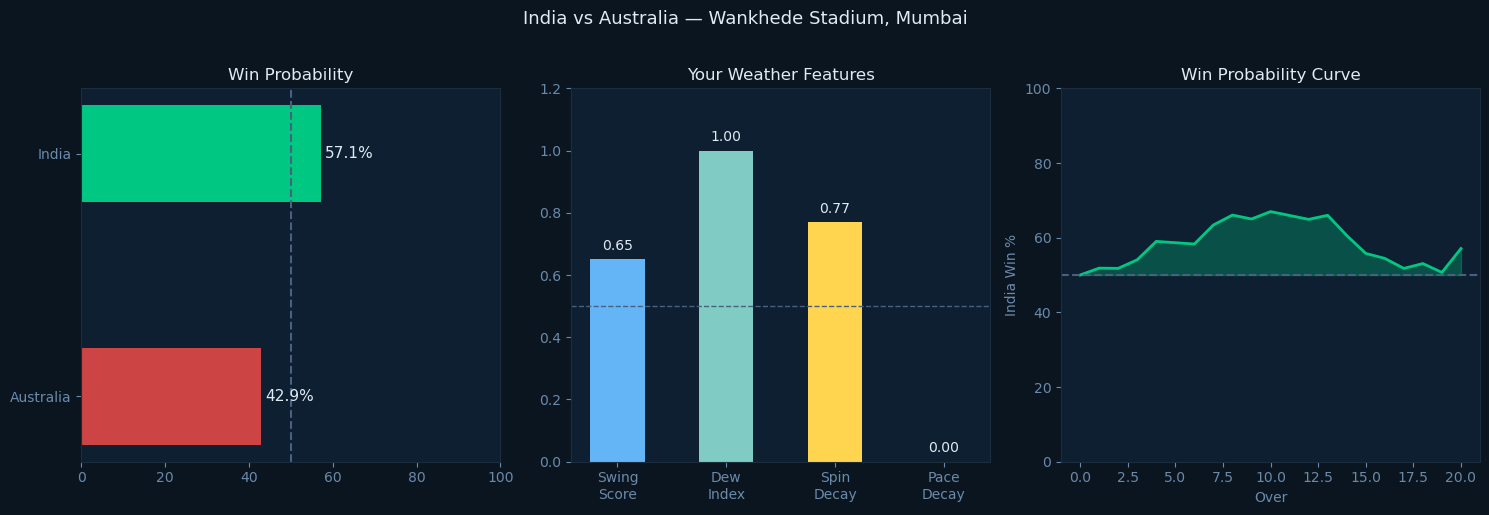

✅ Notebook 4 complete. Your project is ready!


In [7]:
# ── Visualise the prediction ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0a1520')
for ax in axes:
    ax.set_facecolor('#0d1f30')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e2d3d')

# 1. Win probability bar
ax = axes[0]
ax.barh([TEAM2, TEAM1], [team2_prob, team1_prob],
        color=['#cc4444', '#00c882'], edgecolor='none', height=0.4)
ax.axvline(50, color='#4a6080', linestyle='--')
ax.set_xlim(0, 100)
ax.set_title('Win Probability', color='#e0eaf5', fontsize=12)
ax.tick_params(colors='#6b8aaa')
for i, (team, val) in enumerate([(TEAM2, team2_prob), (TEAM1, team1_prob)]):
    ax.text(val+1, i, f'{val}%', va='center', color='#e0eaf5', fontsize=11)

# 2. Weather gauge (radar-style)
ax = axes[1]
categories = ['Swing\nScore', 'Dew\nIndex', 'Spin\nDecay', 'Pace\nDecay']
values     = [swing_score, dew_index, spin_decay, pace_decay]
colors_b   = ['#64b5f6', '#80cbc4', '#ffd54f', '#ce93d8']
bars = ax.bar(categories, values, color=colors_b, edgecolor='none', width=0.5)
ax.set_ylim(0, 1.2)
ax.axhline(0.5, color='#4a6080', linestyle='--', linewidth=1)
ax.set_title('Your Weather Features', color='#e0eaf5', fontsize=12)
ax.tick_params(colors='#6b8aaa')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.03,
            f'{val:.2f}', ha='center', color='#e0eaf5', fontsize=10)

# 3. Simulated win probability curve
ax = axes[2]
overs = np.arange(0, 21)
np.random.seed(42)
drift = (team1_prob - 50) / 20
probs = [50]
for _ in range(20):
    probs.append(np.clip(probs[-1] + drift + np.random.randn()*3, 5, 95))
probs[-1] = team1_prob
ax.fill_between(overs, probs, 50,
                where=[p >= 50 for p in probs], alpha=0.3, color='#00c882')
ax.fill_between(overs, probs, 50,
                where=[p < 50 for p in probs], alpha=0.3, color='#cc4444')
ax.plot(overs, probs, color='#00c882', linewidth=2)
ax.axhline(50, color='#4a6080', linestyle='--')
ax.set_ylim(0, 100)
ax.set_xlabel('Over', color='#6b8aaa')
ax.set_ylabel(f'{TEAM1} Win %', color='#6b8aaa')
ax.set_title('Win Probability Curve', color='#e0eaf5', fontsize=12)
ax.tick_params(colors='#6b8aaa')

plt.suptitle(f'{TEAM1} vs {TEAM2} — {VENUE}',
             color='#e0eaf5', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/processed/prediction_output.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Notebook 4 complete. Your project is ready!')